Используя базу данных автомобилей, создайте сеть с точностью распознавания не ниже 93% на проверочной выборке.

Для решения задачи вы можете использовать любой подход:
- модель без аугментации данных
- аугментация данных с помощью ImageDataGenerator
- аугментация данных с помощью самописного генератора изображений
- использовать готовую архитектуру из набора `tf.keras.applications` (Обратите внимание: на занятии мы не рассматривали данный модуль фреймворка Керас. Ваша задача: попробовать самостоятельно разобраться в приципах его работы. В разборе домашнего задания вы получите ссылку на ноутбук Базы Знаний УИИ, где подробно раскрывается вопрос использования готовых архитектур)

In [1]:
# Ваше решение
# Работа с массивами
import numpy as np

import tensorflow as tf

# Генератор аугментированных изображений
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Основа для создания последовательной модели
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

# Оптимизатор
from tensorflow.keras.optimizers import Adam

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Подключение модуля для загрузки данных из облака
import gdown

# Инструменты для работы с файлами
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Рисование графиков в ячейках Colab
%matplotlib inline

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

In [2]:
# Загрузка zip-архива с датасетом из облака на диск виртуальной машины colab
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l5/middle_fmr.zip', None, quiet=True)

'middle_fmr.zip'

In [3]:
!unzip -qo "middle_fmr.zip" -d /content/cars
IMAGE_PATH = '/content/cars/'

In [4]:
import os

os.listdir(IMAGE_PATH)

['Ferrari', 'Mercedes', 'Renault']

In [5]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 3, метки классов: ['Ferrari', 'Mercedes', 'Renault']


In [6]:
from PIL import Image                     # Отрисовка изображений
import random                             # Генерация случайных чисел
import matplotlib.pyplot as plt           # Отрисовка графиков

%matplotlib inline

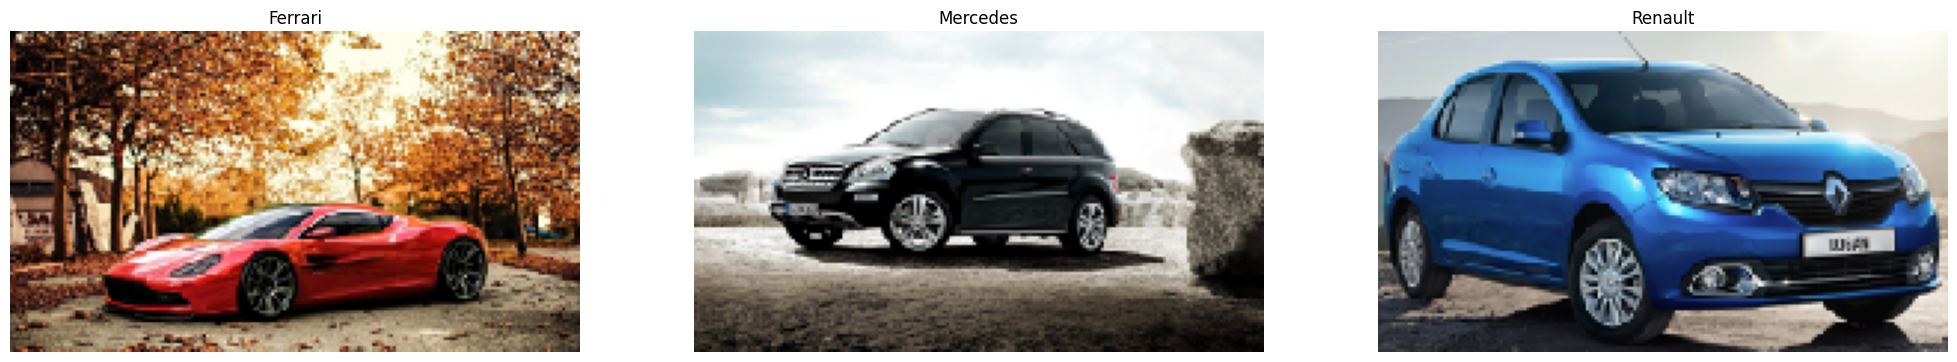

In [7]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(25, 5))

# Для всех номеров классов:
for i in range(CLASS_COUNT):
    # Формирование пути к папке содержимого класса
    car_path = f'{IMAGE_PATH}{CLASS_LIST[i]}/'
    # Выбор случайного фото из i-го класса
    img_path = car_path + random.choice(os.listdir(car_path))
    # Отображение фотографии (подробнее будет объяснено далее)
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')

# Отрисовка всего полотна
plt.show()

Создание списков файлов и их меток класса

In [8]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов, соответствующих файлам

for class_label in range(CLASS_COUNT):    # Для всех классов по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Формирование полного пути к папке с изображениями класса
    class_files = os.listdir(class_path)  # Получение списка имен файлов с изображениями текущего класса
    print(f'Размер класса {class_name} составляет {len(class_files)} машин')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print('Общий размер базы для обучения:', len(data_labels))

Размер класса Ferrari составляет 1088 машин
Размер класса Mercedes составляет 1161 машин
Размер класса Renault составляет 1178 машин
Общий размер базы для обучения: 3427


In [9]:
IMG_WIDTH = 224                           # Ширина изображения
IMG_HEIGHT = 224

In [10]:
import numpy as np                        # Библиотека работы с массивами

data_images = []                          # Пустой список для данных изображений

for file_name in data_files:
    # Открытие и смена размера изображения
    img = Image.open(file_name).convert('RGB').resize((224, 224))
    img_np = np.array(img)                # Перевод в numpy-массив
    data_images.append(img_np)            # Добавление изображения в виде numpy-массива к общему списку

x_data = np.array(data_images)            # Перевод общего списка изображений в numpy-массив
y_data = np.array(data_labels)            # Перевод общего списка меток класса в numpy-массив

print(f'В массив собрано {len(data_images)} фотографий следующей формы: {img_np.shape}')
print(f'Общий массив данных изображений следующей формы: {x_data.shape}')
print(f'Общий массив меток классов следующей формы: {y_data.shape}')

В массив собрано 3427 фотографий следующей формы: (224, 224, 3)
Общий массив данных изображений следующей формы: (3427, 224, 224, 3)
Общий массив меток классов следующей формы: (3427,)


In [11]:
# Подключение нужных слоев из модуля tensorflow.keras.layers

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization

Аугументируем данные

In [12]:
train_datagen = ImageDataGenerator(
    rotation_range=5, #случайный поворот изображения в диапазоне ±5 градусов
    width_shift_range=0.05, # сдвиг по горизонтали до 5% ширины
    height_shift_range=0.05,
    zoom_range=0.1, # случайный зум (приближение/отдаление) до ±10%
    horizontal_flip=True #случайное отражение по горизонтали (зеркально)
)

val_datagen = ImageDataGenerator()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_data, y_data, test_size=0.2, stratify=y_data
)

In [14]:
#Создаётся генератор батчей для обучения:
train_generator = train_datagen.flow(
    X_train, y_train, batch_size=32
)

val_generator = val_datagen.flow(
    X_val, y_val, batch_size=32
)

In [15]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),# уменьшает размер в 2 раза

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(CLASS_COUNT, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
#останавливаем обучение если 3 эпохи нет изменений
early_stop = EarlyStopping(patience=7, restore_best_weights=True)
#уменьшаем learning rate, если обучение застряло.
lr_scheduler = ReduceLROnPlateau(
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
store_learning = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 54s 492ms/step - accuracy: 0.5038 - loss: 1.0186 - val_accuracy: 0.4942 - val_loss: 1.0001 - learning_rate: 3.0000e-04
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 390ms/step - accuracy: 0.5611 - loss: 0.8990 - val_accuracy: 0.5612 - val_loss: 0.9134 - learning_rate: 3.0000e-04
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 368ms/step - accuracy: 0.5801 - loss: 0.8606 - val_accuracy: 0.5539 - val_loss: 0.9321 - learning_rate: 3.0000e-04
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 382ms/step - accuracy: 0.5998 - loss: 0.8546 - val_accuracy: 0.4344 - val_loss: 1.2280 - learning_rate: 3.0000e-04
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 365ms/step - accuracy: 0.5961 - loss: 0.8386 - val_accuracy: 0.5889 - val_loss: 0.8849 - learning_rate: 3.0000e-04
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 378ms/step - accuracy: 0.6239 - loss: 0.8215 - val_accuracy: 0.6327 - val_loss: 0.8858 - learning_rate: 3.0000e-04
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 361ms/step - acc

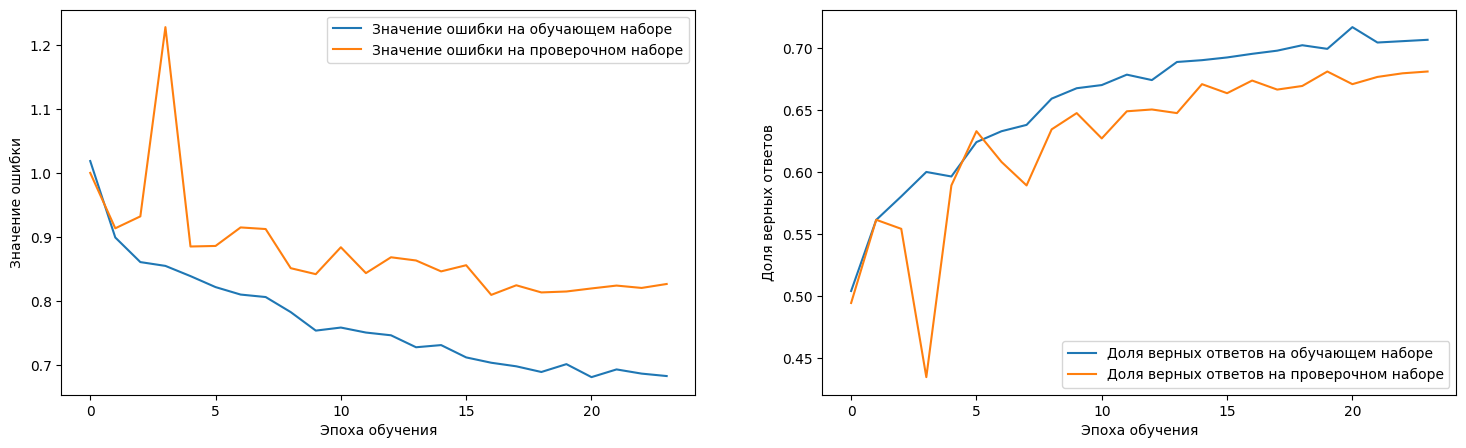

In [19]:
# Создание полотна для рисунка
plt.figure(1, figsize=(18, 5))

# Задание первой (левой) области для построения графиков
plt.subplot(1, 2, 1)
# Отрисовка графиков 'loss' и 'val_loss' из значений словаря store_learning.history
plt.plot(store_learning.history['loss'],
         label='Значение ошибки на обучающем наборе')
plt.plot(store_learning.history['val_loss'],
         label='Значение ошибки на проверочном наборе')
# Задание подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение ошибки')
plt.legend()

# Задание второй (правой) области для построения графиков
plt.subplot(1, 2, 2)
# Отрисовка графиков 'accuracy' и 'val_accuracy' из значений словаря store_learning.history
plt.plot(store_learning.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(store_learning.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
# Задание подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()

# Фиксация графиков и рисование всей картинки
plt.show()

Несмотря на использование аугментации и оптимизации архитектуры, точность модели, обученной с нуля, не достигает нужных 93%. Это связано с недостаточным объёмом данных и сложностью задачи. Для достижения требуемой точности необходимо использовать предобученные модели.


In [54]:
#нормализация входа
from tensorflow.keras.applications.efficientnet import preprocess_input

X_train_p = preprocess_input(X_train.copy())
X_val_p   = preprocess_input(X_val.copy())

In [44]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),#поворот до ~5% круга (~±18°)
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),#изменение контраста
])

In [45]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_augmentation(inputs) # к входу применяются преобразования
x = preprocess_input(x) #переводит пиксели в диапазон

base_model = EfficientNetB0(include_top=False, weights='imagenet')# загружаем предобученную модель и убирается классификатор
base_model.trainable = False

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) #превращает 3D карты признаков в вектор
x = Dense(128, activation='relu')(x)#Классификатор
x = Dropout(0.5)(x)
outputs = Dense(CLASS_COUNT, activation='softmax')(x) # выдача вероятности классов

model = Model(inputs, outputs)


In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=3, restore_best_weights=True)
#уменьшаем learning rate, если обучение застряло.
lr_scheduler = ReduceLROnPlateau(
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [48]:
history1 = model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)


Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.7486 - loss: 0.5715 - val_accuracy: 0.8222 - val_loss: 0.4209 - learning_rate: 0.0010
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.8296 - loss: 0.4374 - val_accuracy: 0.8528 - val_loss: 0.3794 - learning_rate: 0.0010
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.8501 - loss: 0.3733 - val_accuracy: 0.8513 - val_loss: 0.3719 - learning_rate: 0.0010
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.8643 - loss: 0.3490 - val_accuracy: 0.8630 - val_loss: 0.3693 - learning_rate: 0.0010
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.8781 - loss: 0.3140 - val_accuracy: 0.8644 - val_loss: 0.3671 - learning_rate: 0.0010
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.8865 - loss: 0.2820 - val_accuracy: 0.8717 - val_loss: 0.3411 - learning_rate: 0.0010
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.8938 - loss: 0.2696 - val_

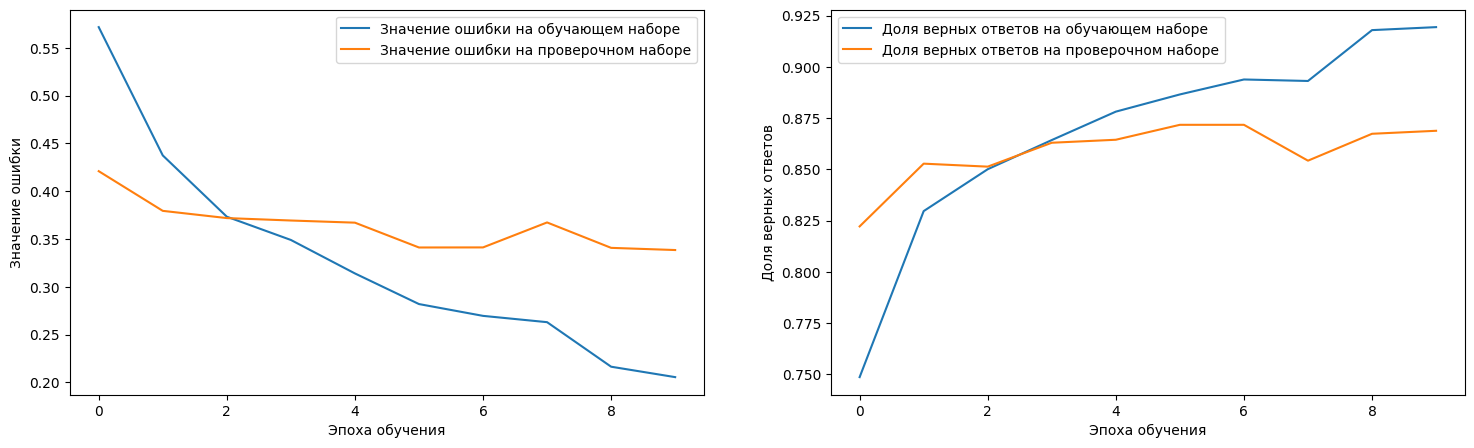

In [49]:
# Создание полотна для рисунка
plt.figure(1, figsize=(18, 5))

# Задание первой (левой) области для построения графиков
plt.subplot(1, 2, 1)
# Отрисовка графиков 'loss' и 'val_loss' из значений словаря store_learning.history
plt.plot(history1.history['loss'],
         label='Значение ошибки на обучающем наборе')
plt.plot(history1.history['val_loss'],
         label='Значение ошибки на проверочном наборе')
# Задание подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение ошибки')
plt.legend()

# Задание второй (правой) области для построения графиков
plt.subplot(1, 2, 2)
# Отрисовка графиков 'accuracy' и 'val_accuracy' из значений словаря store_learning.history
plt.plot(history1.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history1.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
# Задание подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()

# Фиксация графиков и рисование всей картинки
plt.show()

Попробуем еще поднять точность

In [ ]:
# Проходим по всем слоям базовой модели
for layer in base_model.layers:

   # Если слой — BatchNormalization
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        # BatchNorm хранит статистики (mean/variance), полученные на большом датасете 
        # Если их обновлять на маленьком датасете, оценки станут шумными и ухудшат качество модели.
        # Поэтому сохраняем предобученные статистики и не обучаем этот слой.
       

    else:
        layer.trainable = True
        # Все остальные слои обучаем


In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history2 = model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 45s 277ms/step - accuracy: 0.9318 - loss: 0.1842 - val_accuracy: 0.8776 - val_loss: 0.3181 - learning_rate: 1.0000e-05
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step - accuracy: 0.9365 - loss: 0.1613 - val_accuracy: 0.8950 - val_loss: 0.2983 - learning_rate: 1.0000e-05
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.9442 - loss: 0.1481 - val_accuracy: 0.8994 - val_loss: 0.2890 - learning_rate: 1.0000e-05
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.9515 - loss: 0.1369 - val_accuracy: 0.9038 - val_loss: 0.2783 - learning_rate: 1.0000e-05
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 237ms/step - accuracy: 0.9566 - loss: 0.1217 - val_accuracy: 0.9067 - val_loss: 0.2845 - learning_rate: 1.0000e-05
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 239ms/step - accuracy: 0.9504 - loss: 0.1293 - val_accuracy: 0.8994 - val_loss: 0.2671 - learning_rate: 1.0000e-05
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 239ms/step - acc

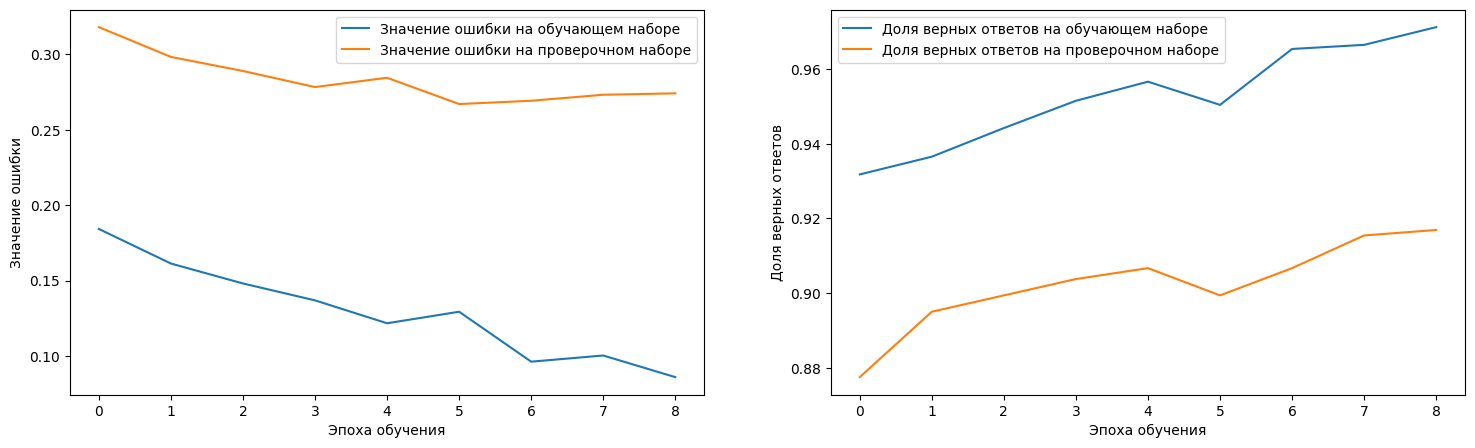

In [53]:
# Создание полотна для рисунка
plt.figure(1, figsize=(18, 5))

# Задание первой (левой) области для построения графиков
plt.subplot(1, 2, 1)
# Отрисовка графиков 'loss' и 'val_loss' из значений словаря store_learning.history
plt.plot(history2.history['loss'],
         label='Значение ошибки на обучающем наборе')
plt.plot(history2.history['val_loss'],
         label='Значение ошибки на проверочном наборе')
# Задание подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение ошибки')
plt.legend()

# Задание второй (правой) области для построения графиков
plt.subplot(1, 2, 2)
# Отрисовка графиков 'accuracy' и 'val_accuracy' из значений словаря store_learning.history
plt.plot(history2.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history2.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
# Задание подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()

# Фиксация графиков и рисование всей картинки
plt.show()